In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

In [2]:
#Data can be downloaded from https://mortality.org/
USA = pd.read_csv("C:/Python/Wasserstein/bltper_1x1_US.txt", sep="\s+", skiprows=2)
Germany = pd.read_csv("C:/Python/Wasserstein/bltper_1x1_Germany.txt", sep="\s+", skiprows=2)

In [3]:
# Please note that I use "lx" and "Sx" interchangeable for denoting the survivorship function.

def get_dx(df, year):
    qx = df.loc[df["Year"] == year, "qx"].values
    lx = np.concatenate(([1], np.cumprod(1 - qx)[:-1]))
    dx = np.concatenate((-np.diff(lx), [lx[-1]]))
    return dx

def get_e0(df, year):
    ex = df.loc[df["Year"] == year, "ex"].values
    e0 = ex[0]
    return e0

def plot_dx(ages, dx1, dx2, e0_1, e0_2, label1, label2):
    plt.figure(figsize=(10, 6))
    plt.plot(ages, dx1, label=f"{label1} (e₀ = {e0_1:.1f})", marker='o')
    plt.plot(ages, dx2, label=f"{label2} (e₀ = {e0_2:.1f})", marker='s')
    plt.text(ages[np.argmax(dx1)]-10, max(dx1), f"e₀ = {e0_1:.1f}", fontsize=10, ha='left', va='bottom')
    plt.text(ages[np.argmax(dx2)]-10, max(dx2), f"e₀ = {e0_2:.1f}", fontsize=10, ha='left', va='bottom')
    plt.title("Comparison of Death Distributions by Age")
    plt.xlabel("Age")
    plt.ylabel("dx (number of deaths)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_Sx(ages, Sx1, Sx2, label1, label2):
    plt.figure(figsize=(10, 6))
    plt.plot(ages, Sx1, label=f"{label1}", marker='o')
    plt.plot(ages, Sx2, label=f"{label2}", marker='s')
    plt.fill_between(ages, Sx1, Sx2, color='gray', alpha=0.4)
    plt.title("Comparison of survivorship functions")
    plt.xlabel("Age")
    plt.ylabel("Proportion of being alive")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def get_Sx(dx):
    CDF = np.cumsum(dx)
    Sx = 1 - CDF
    return Sx

def get_Wasserstein(dx1, dx2):
    CDF1 = np.cumsum(dx1)
    Sx1 = 1 - CDF1
    CDF2 = np.cumsum(dx2)
    Sx2 = 1 - CDF2
    Sx_diff_absolute = abs(Sx1 - Sx2)
    Wasserstein = round(np.sum(Sx_diff_absolute), 2)
    return Wasserstein  

In [5]:
dx_1980_US = get_dx(USA, 1980)
dx_1990_US = get_dx(USA, 1990)
dx_2019_US = get_dx(USA, 2019)

ages = np.arange(len(dx_1980_US))

dx_1990_Germany = get_dx(Germany, 1990)

e0_1980_US = get_e0(USA, 1980)
e0_1990_US = get_e0(USA, 1990)
e0_2019_US = get_e0(USA, 2019)
e0_1990_Germany = get_e0(Germany, 1990)

Sx_1980_US = get_Sx(dx_1980_US)
Sx_1990_US = get_Sx(dx_1990_US)
Sx_2019_US = get_Sx(dx_2019_US)
Sx_1990_Germany = get_Sx(dx_1990_Germany)


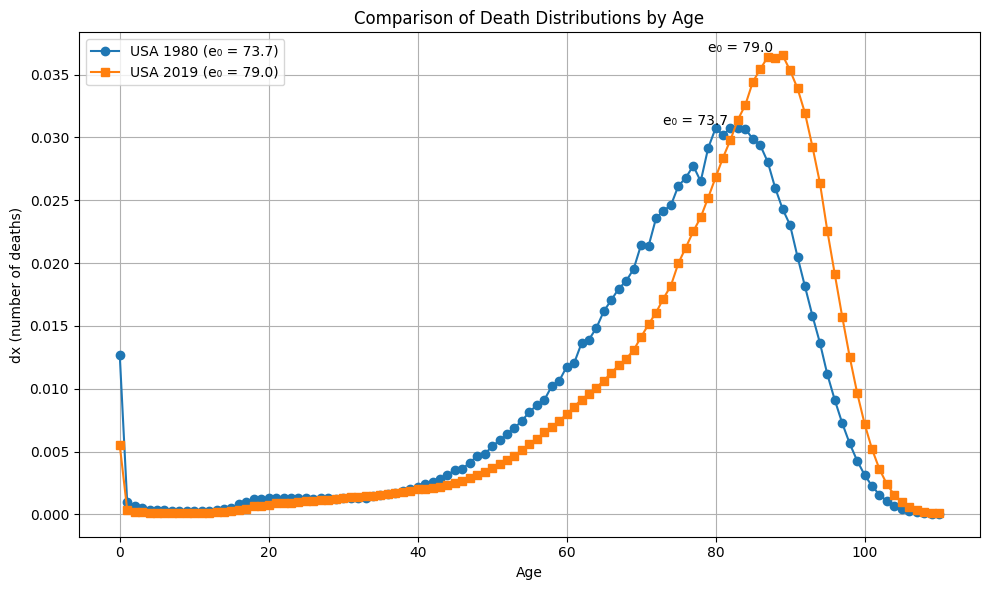

In [6]:
plot_dx(ages, dx_1980_US, dx_2019_US, e0_1980_US, e0_2019_US, "USA 1980", "USA 2019")


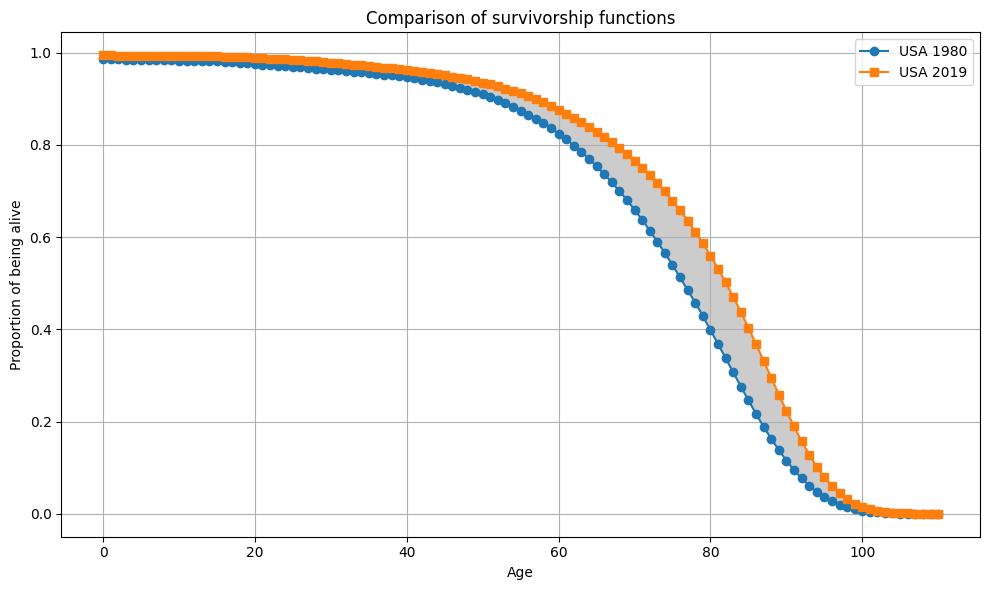

In [7]:
plot_Sx(ages, Sx_1980_US, Sx_2019_US, "USA 1980", "USA 2019")

In [10]:
condition = np.all(Sx_2019_US >= Sx_1980_US)
if condition:
    print("Sx1 >= Sx2 for all x")
else:
    print("Sx1 not always >= Sx2 for all x")



Difference_in_e0_US_2019_and_US_1980 = round(e0_2019_US - e0_1980_US, 2)
Wasserstein_between_2019_US_1980_US = get_Wasserstein(dx_2019_US, dx_1980_US)
Wasserstein_scipy = round(wasserstein_distance(ages, ages, dx_2019_US, dx_1980_US), 2)

print(f"The difference in e0 is: {Difference_in_e0_US_2019_and_US_1980}")
print(f"The Wasserstein distance is: {Wasserstein_between_2019_US_1980_US}")
print(f"The Wasserstein distance from Scipy: {Wasserstein_scipy}")


Sx1 >= Sx2 for all x
The difference in e0 is: 5.21
The Wasserstein distance is: 5.21
The Wasserstein distance from Scipy: 5.21


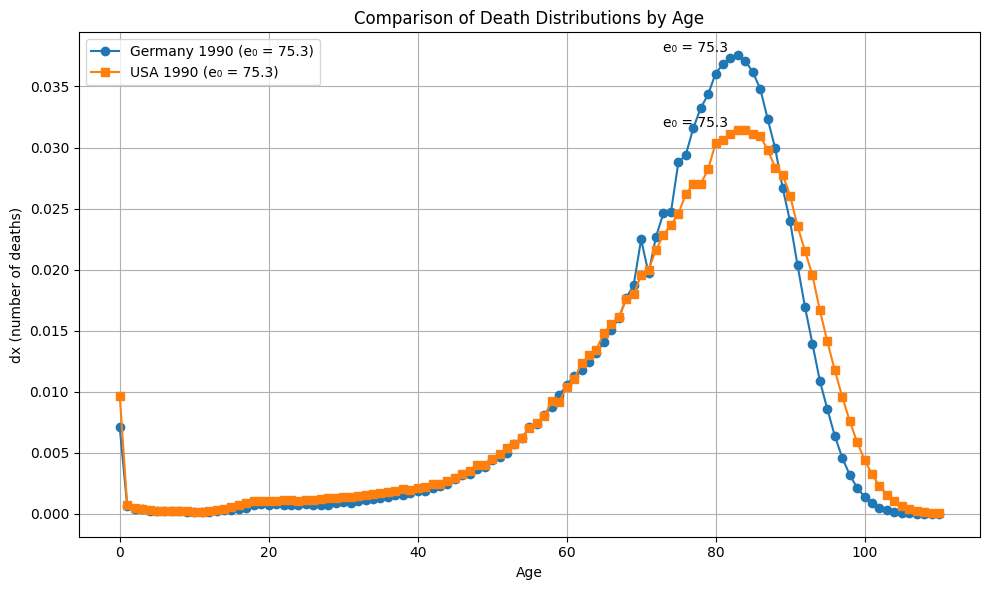

In [11]:
plot_dx(ages, dx_1990_Germany, dx_1990_US, e0_1990_Germany, e0_1990_Germany, "Germany 1990", "USA 1990")

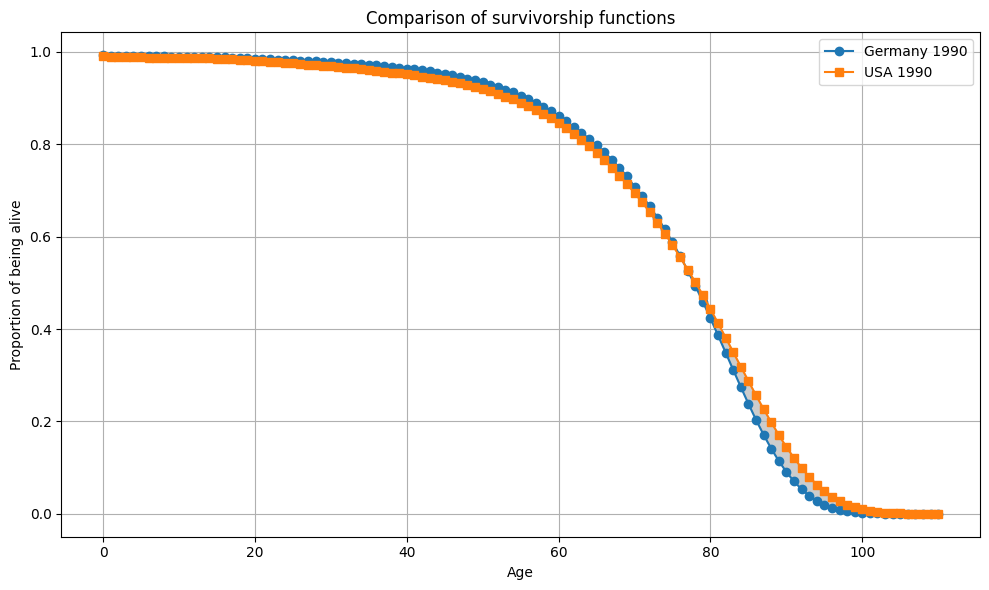

In [12]:
plot_Sx(ages, Sx_1990_Germany, Sx_1990_US, "Germany 1990", "USA 1990")

In [14]:
condition = np.all(Sx_1990_Germany >= Sx_1990_US)
if condition:
    print("Sx1 >= Sx2 for all x")
else:
    print("Sx1 not always >= Sx2 for all x")

Difference_in_e0_Germany_1990_and_US_1990 = round(e0_1990_Germany - e0_1990_US, 2)
Wasserstein_between_Germany_1990_US_1990_US = get_Wasserstein(dx_1990_Germany, dx_1990_US)
Wasserstein_scipy = round(wasserstein_distance(ages, ages, dx_1990_Germany, dx_1990_US), 2)

print(f"The difference in e0 is: {Difference_in_e0_Germany_1990_and_US_1990}")
print(f"The Wasserstein distance is: {Wasserstein_between_Germany_1990_US_1990_US}")
print(f"The Wasserstein distance from Scipy is: {Wasserstein_scipy}")

Sx1 not always >= Sx2 for all x
The difference in e0 is: -0.05
The Wasserstein distance is: 1.56
The Wasserstein distance from Scipy is: 1.56
